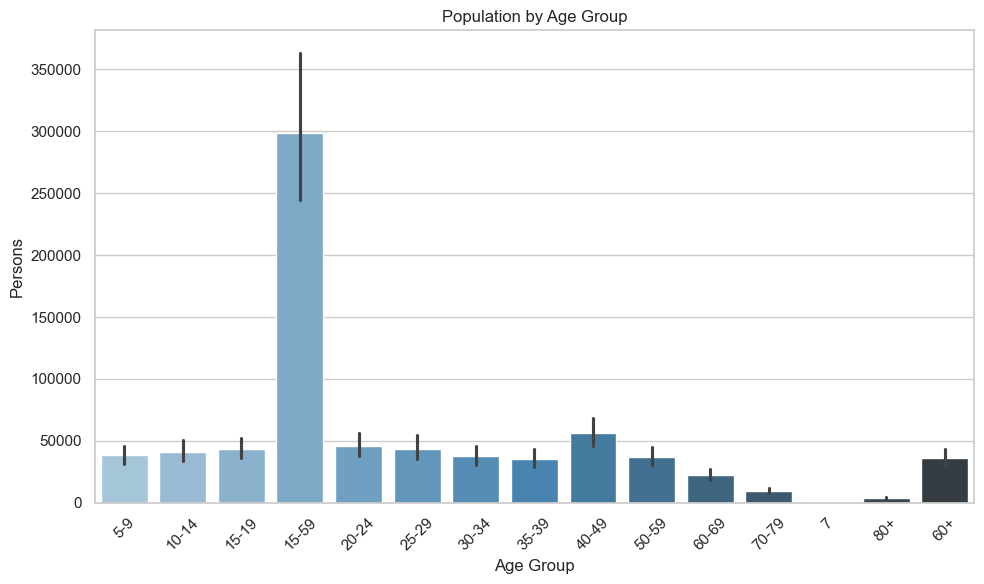

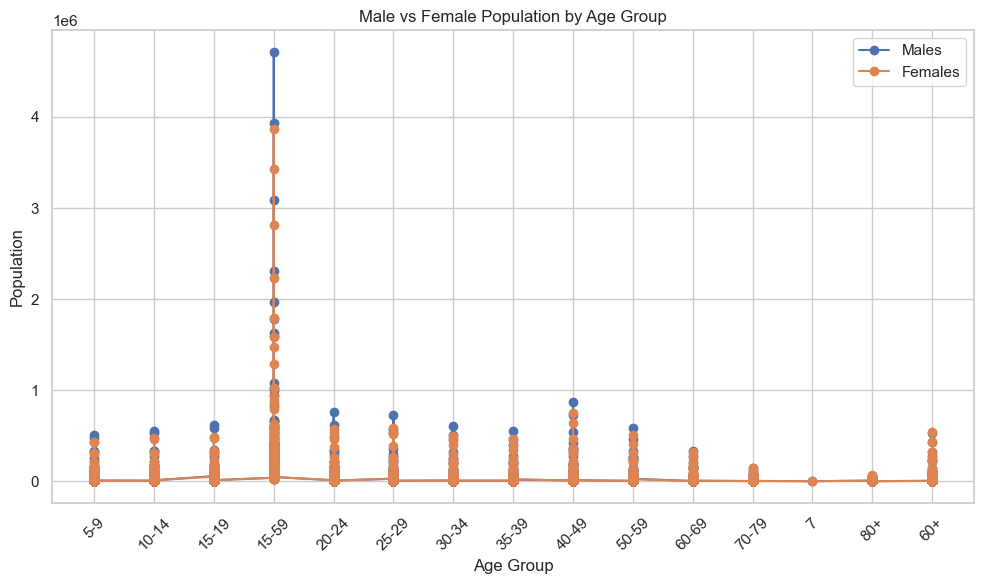

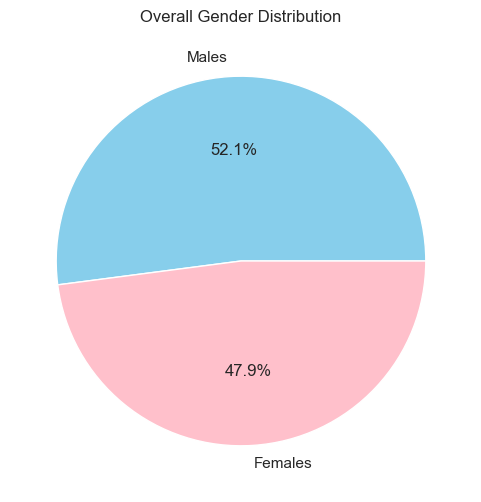

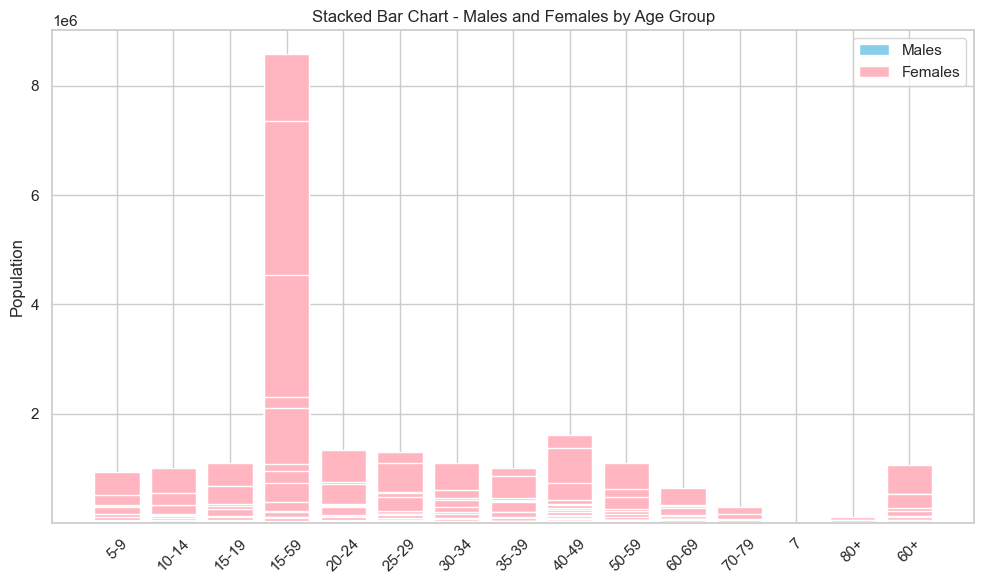

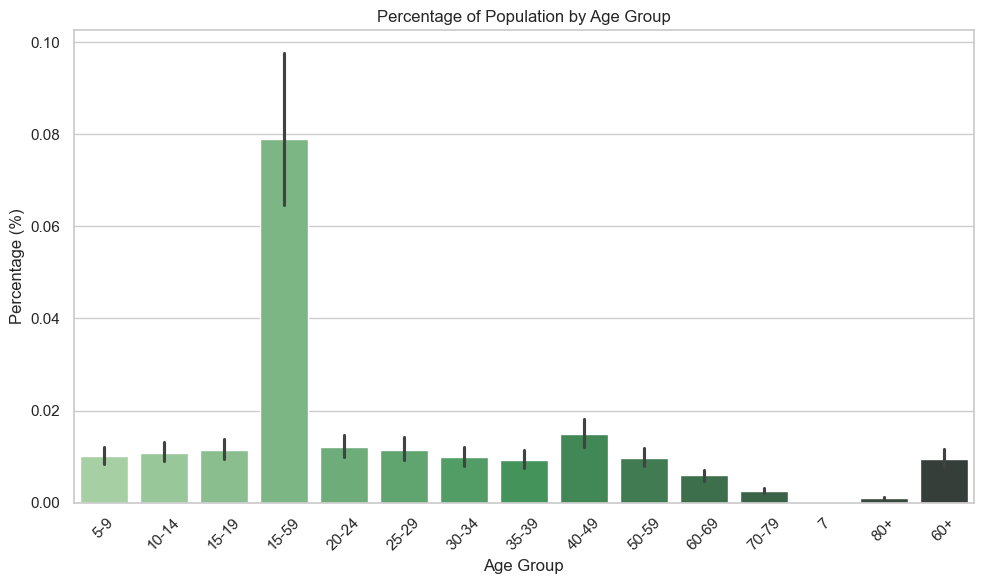

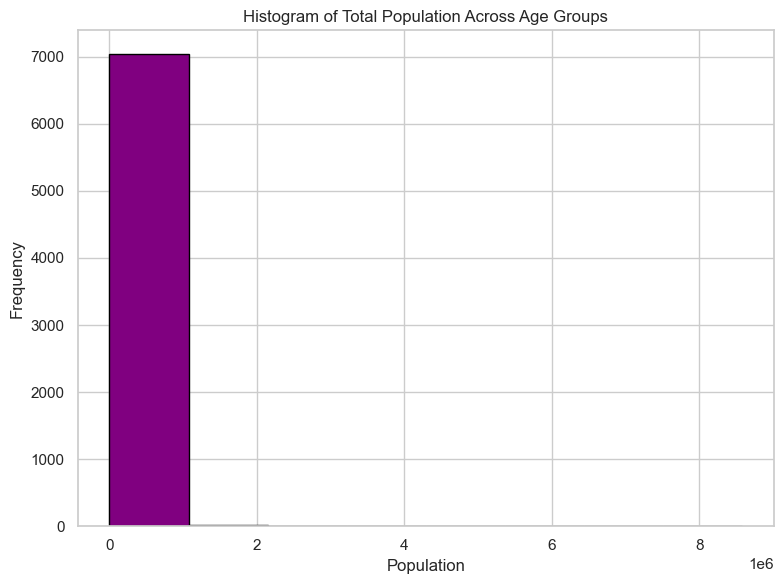

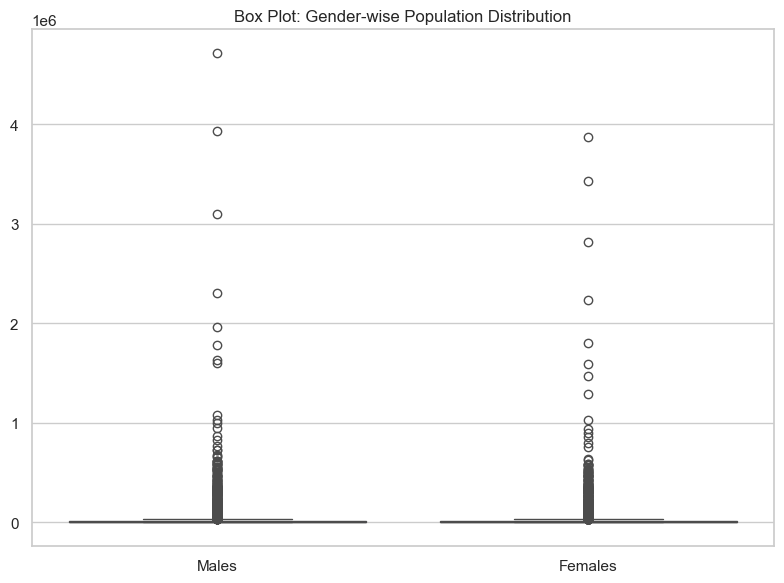

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


# Load the data
file_path = (r"C:\Users\saksh\Downloads\pythonproject.xls")
df = pd.read_excel(file_path, sheet_name='B01', skiprows=5)

# Rename columns
df = df.rename(columns={
    'Unnamed: 5': 'Age Group',
    'Unnamed: 6': 'Persons',
    'Unnamed: 7': 'Males',
    'Unnamed: 8': 'Females'
})

# Drop invalid and convert
df.dropna(subset=['Age Group', 'Persons', 'Males', 'Females'], inplace=True)
df['Persons'] = pd.to_numeric(df['Persons'], errors='coerce')
df['Males'] = pd.to_numeric(df['Males'], errors='coerce')
df['Females'] = pd.to_numeric(df['Females'], errors='coerce')
df.dropna(inplace=True)

# Clean 'Age Group'
df['Age Group'] = df['Age Group'].astype(str)
df = df[df['Age Group'].str.contains(r'\d', regex=True)]
df['Age Group'] = pd.Categorical(df['Age Group'], 
    categories=sorted(df['Age Group'].unique(), key=lambda x: int(x.split('-')[0]) if '-' in x else 100), 
    ordered=True)
df.sort_values('Age Group', inplace=True)

sns.set(style="whitegrid")

# 1. Bar Plot – Total Persons by Age Group
plt.figure(figsize=(10, 6))
sns.barplot(x='Age Group', y='Persons', data=df, palette='Blues_d')
plt.title('Population by Age Group')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show(block=True)

# 2. Line Plot – Males vs Females
plt.figure(figsize=(10, 6))
plt.plot(df['Age Group'], df['Males'], marker='o', label='Males')
plt.plot(df['Age Group'], df['Females'], marker='o', label='Females')
plt.title('Male vs Female Population by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Population')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show(block=True)

# 3. Pie Chart – Gender Distribution
total_males = df['Males'].sum()
total_females = df['Females'].sum()
plt.figure(figsize=(6, 6))
plt.pie([total_males, total_females], labels=['Males', 'Females'], autopct='%1.1f%%', colors=['skyblue', 'pink'])
plt.title('Overall Gender Distribution')
plt.show(block=True)

# 4. Stacked Bar Chart – Males and Females by Age Group
plt.figure(figsize=(10, 6))
plt.bar(df['Age Group'], df['Males'], label='Males', color='skyblue')
plt.bar(df['Age Group'], df['Females'], bottom=df['Males'], label='Females', color='lightpink')
plt.title('Stacked Bar Chart - Males and Females by Age Group')
plt.ylabel('Population')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show(block=True)

# 5. Percentage Distribution by Age Group
df['Percent'] = (df['Persons'] / df['Persons'].sum()) * 100
plt.figure(figsize=(10, 6))
sns.barplot(x='Age Group', y='Percent', data=df, palette='Greens_d')
plt.title('Percentage of Population by Age Group')
plt.xticks(rotation=45)
plt.ylabel('Percentage (%)')
plt.tight_layout()
plt.show(block=True)

# 6. Histogram – Total Persons Distribution
plt.figure(figsize=(8, 6))
plt.hist(df['Persons'], bins=8, color='purple', edgecolor='black')
plt.title('Histogram of Total Population Across Age Groups')
plt.xlabel('Population')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show(block=True)

# 7. Box Plot – Spread of Males and Females
plt.figure(figsize=(8, 6))
sns.boxplot(data=df[['Males', 'Females']])
plt.title('Box Plot: Gender-wise Population Distribution')
plt.tight_layout()
plt.show(block=True)

# 8. Heatmap – Scaled Gender Values
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled = pd.DataFrame(scaler.fit_transform(df[['Males', 'Females']]), columns=['Males', 'Females'])
plt.figure(figsize=(6, 4))
sns.heatmap(scaled.T, cmap='coolwarm', cbar=True, xticklabels=df['Age Group'])
plt.title('Heatmap of Normalized Gender Data by Age Group')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show(block=True)

# 9. Gender Ratio (Males per 100 Females)
df['Gender Ratio'] = (df['Males'] / df['Females']) * 100
plt.figure(figsize=(10, 6))
sns.barplot(x='Age Group', y='Gender Ratio', data=df, palette='coolwarm')
plt.axhline(100, color='gray', linestyle='--')
plt.title('Gender Ratio (Males per 100 Females) by Age Group')
plt.ylabel('Males per 100 Females')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show(block=True)


# 10. Area Plot – Males & Females by Age Group
plt.figure(figsize=(10, 6))
plt.stackplot(df['Age Group'], df['Males'], df['Females'], labels=['Males', 'Females'], colors=['skyblue', 'lightpink'])
plt.title('Area Plot of Gender-wise Population by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Population')
plt.legend(loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show(block=True)

# 11. Violin Plot – Gender Distribution
# Prepare melt-style DataFrame for violin plot
melted_df = pd.melt(df, value_vars=['Males', 'Females'], var_name='Gender', value_name='Population')

plt.figure(figsize=(8, 6))
sns.violinplot(x='Gender', y='Population', data=melted_df, palette='pastel')
plt.title('Violin Plot of Male and Female Population Distribution')
plt.tight_layout()
plt.show(block=True)

# 12. Dataset Overview
print("Dataset Overview:")
print(df.info())  # Summary of the DataFrame (columns, non-null counts, data types)

print("\nDataset Description (Numerical Data):")
print(df.describe())  # Summary statistics for numerical columns

print("\nMissing Values:")
print(df.isnull().sum())  # Check for missing values

print("\nAge Groups Available:")
print(df['Age Group'].unique())  # List all unique Age Groups

print("\nTotal Population (Sum of Persons):")
print(f"Total Population: {df['Persons'].sum()}")  # Total population across all age groups

# Gender statistics
total_males = df['Males'].sum()
total_females = df['Females'].sum()

print(f"\nTotal Males: {total_males}")
print(f"Total Females: {total_females}")

# Gender Ratio (Males per 100 Females) calculation
gender_ratio = (total_males / total_females) * 100 if total_females != 0 else None
print(f"\nGender Ratio (Males per 100 Females): {gender_ratio if gender_ratio else 'undefined (no females in dataset)'}")



# 13. Line Plot – Males vs Females by Age Group
plt.figure(figsize=(10, 6))
plt.plot(df['Age Group'], df['Males'], marker='o', label='Males', color='skyblue')
plt.plot(df['Age Group'], df['Females'], marker='o', label='Females', color='lightpink')
plt.title('Males vs Females by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Population')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

